# 03. MATPOWER와 pandapower baseline

**목표**
- 02에서 본 Newton 구조가 pandapower와 MATPOWER에서 어떻게 실행되는지 비교한다.
- 성능 결론보다 기준선의 의미를 먼저 정리한다.
- 이후 cuPF가 바꾸는 지점을 `Jacobian`과 `linear solve`로 분리해 읽을 준비를 한다.

**비교 대상**
- `pypower-pandapower`: pandapower 안의 PYPOWER-derived Newton path
- `matpower-default`: MATLAB/MATPOWER의 AC Newton-Raphson path

**케이스 선택**
- `case9`: 수식과 구조를 설명하기 위한 작은 예제
- `case6468rte`: sparse Jacobian과 sparse linear solve 비용이 드러나는 baseline 예제


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

plt.rcParams['figure.figsize'] = (8, 4.8)
plt.rcParams['axes.grid'] = False
pd.set_option('display.max_colwidth', 120)

TUTORIAL_CASE = tu.TUTORIAL_LARGE_CASE
RUN_BENCHMARKS = True
REPEATS = 1
WARMUP = 0


**MATLAB/MATPOWER 환경**
- 설정 위치: repo root `.env` 또는 process environment
- 기본 경로: `/workspace/gpu-powerflow-master/.env`
- 비밀값 출력 정책: 값은 출력하지 않고 set/unset 여부만 확인한다.

**필요할 수 있는 변수**
- online licensing: `MATLAB_LICMODE=onlinelicensing`, `MATLAB_USER_ID`, `MATLAB_PASSWORD`
- MATLAB/MATPOWER 위치: `MATLAB_BIN`, `MATPOWER_HOME`
- license server/file: `MATLAB_LICENSE_FILE` 또는 `MLM_LICENSE_FILE`


In [2]:
case = tu.load_case(TUTORIAL_CASE)
print(f"case={case.case_name}, buses={case.ybus.shape[0]}, ybus_nnz={case.ybus.nnz}, pv={len(case.pv)}, pq={len(case.pq)}")
display(tu.matlab_env_summary())
display(tu.solver_path_table().iloc[:2])
print(tu.print_environment_note())


case=case6468rte, buses=6468, ybus_nnz=22598, pv=641, pq=5826


,key,status,source,secret
0,MATLAB_BIN,unset,,no
1,MATPOWER_HOME,set,process env,no
2,MATLAB_LICMODE,unset,,no
3,MATLAB_USER_ID,set,.env,yes
4,MATLAB_PASSWORD,set,.env,yes
5,MATLAB_LICENSE_FILE,unset,,no
6,MLM_LICENSE_FILE,unset,,no


,Path,Jacobian,Linear solver,Benchmark ID
0,pandapower PYPOWER-derived NR,pandapower.pypower dSbus_dV sparse block assembly,scipy.sparse.linalg.spsolve; SuperLU here unless scikits.umfpack is installed,pypower-pandapower
1,MATPOWER default,MATPOWER makeJac/dSbus_dV NR Jacobian,MATLAB default sparse solve,matpower-default


pandapower.pypower.newtonpf calls scipy.sparse.linalg.spsolve; scikits.umfpack is not installed; SciPy spsolve uses SuperLU-style path here.


**Python Newton stage 분해**
- 목적: 큰 케이스에서 비용이 어느 단계에 모이는지 확인한다.
- 주의: pandapower 내부의 모든 옵션을 그대로 재현한 profiler가 아니다.
- 읽는 법: 절대 시간보다 `mismatch`, `Jacobian`, `linear solve`, `update`의 상대적 위치를 본다.


converged=True, iterations=3, final_mismatch=7.732e-12


,time_ms
stage,
Linear solve,42.675
Jacobian,24.321
Voltage update,0.999
Mismatch,0.655


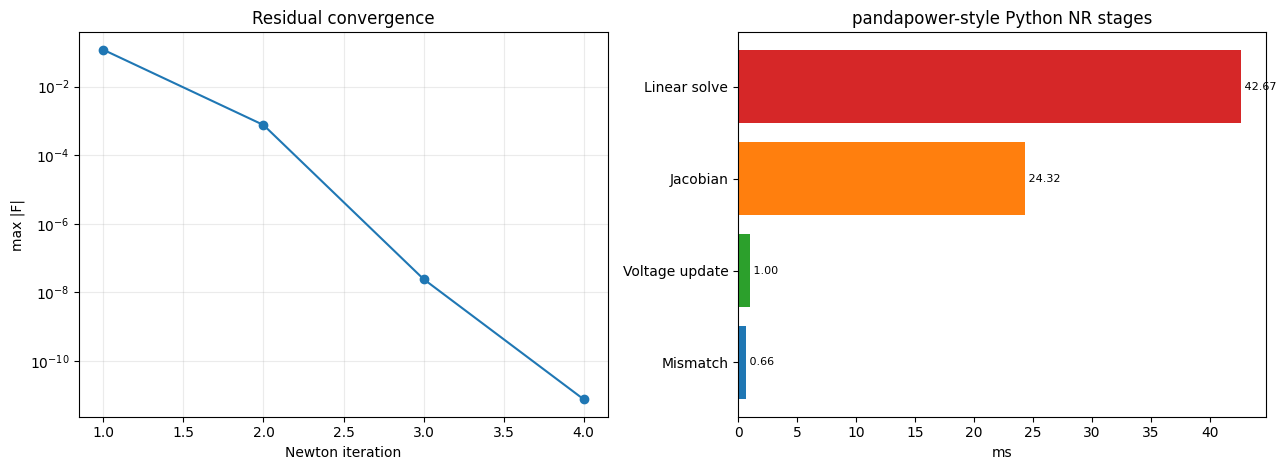

In [3]:
trace = tu.newton_trace(case, tolerance=1e-8, max_iter=50)
print(f"converged={trace.converged}, iterations={trace.iterations}, final_mismatch={trace.final_mismatch:.3e}")
display(trace.stage_totals_ms.rename('time_ms').to_frame().round(3))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
tu.plot_newton_convergence(trace, axes[0])
tu.plot_stage_timing(trace.stage_totals_ms, axes[1], 'pandapower-style Python NR stages')
plt.tight_layout()


**Baseline 실행**
- 실행 대상: pandapower-derived path, MATPOWER default
- 기본 설정: `repeats=1`, `warmup=0`
- 보고용 평균: 상단 `REPEATS`를 5 이상으로 바꿔 재실행
- 결과 위치: `python/tutorial/_runs/...`, git에는 포함하지 않음


$ /usr/bin/python3 -m python.tests.run_benchmark --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --run-name tutorial-baseline-20260601-140441 --cases case6468rte --repeats 1 --warmup 0 --variants pypower-pandapower matpower-default
[OK] elapsed=16.5s
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_pypower --dataset-root /datasets/matpower --run-name tutorial-baseline-20260601-140441 --output-root /workspace/gpu-powerflow-master/python/tutorial/_runs --warmup 0 --repeats 1 --tolerance 1e-08 --max-iter 50 --reference-tolerance 1e-10 --reference-max-iter 80 --no-aggregate --cases case6468rte
[pypower-pandapower][OK] case6468rte repeat=0 init_ms=266.747 solve_ms=73.515 iters=3 resid=7.732e-12
[pypower-pandapower] wrote /workspace/gpu-powerflow-master/python/tutorial/_runs/tutorial-baseline-20260601-140441/pypower-pandapower/runs.csv
[benchmark][RUN] /usr/bin/python3 -m python.tests.run_matpower --dataset-root /datasets/matpower --run-name tutorial-baseline-2026060

,variant,status,linear_solver,initialize_ms,solve_ms,worst_residual,note
1,pypower-pandapower,ok,scipy-spsolve,266.746616,73.514903,7.732085e-12,
0,matpower-default,ok,default,389.561000,1038.489000,1.781664e-11,


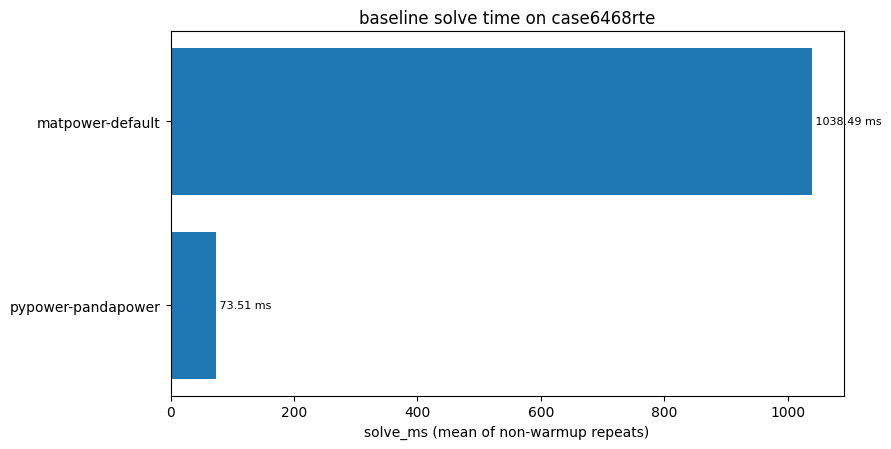

In [4]:
variants = ['pypower-pandapower', 'matpower-default']
if RUN_BENCHMARKS:
    run_dir, command = tu.run_tutorial_benchmark(
        variants=variants,
        run_name=tu.timestamp_run_name('tutorial-baseline'),
        cases=[TUTORIAL_CASE],
        repeats=REPEATS,
        warmup=WARMUP,
        timeout=7200,
    )
    print(tu.command_summary(command, tail_lines=18))
else:
    run_dir = tu.tutorial_output_root()

summary = tu.benchmark_result_table(run_dir)
display(summary[['variant', 'status', 'linear_solver', 'initialize_ms', 'solve_ms', 'worst_residual', 'note']])
fig, ax = plt.subplots(figsize=(9, 4.6))
tu.plot_variant_timing(summary, ax, 'baseline solve time on case6468rte')
plt.tight_layout()


**Baseline 결과 해석**
- 이 표의 핵심은 `pandapower가 MATPOWER보다 우월하다`가 아니다.
- 같은 Newton 구조라도 Python runner와 MATLAB/MATPOWER runner는 end-to-end 측정 구간이 다르다.
- 현재 저장된 출력에서는 MATPOWER default의 `solve_ms`가 pandapower-derived path보다 훨씬 길게 측정됐다.
- 이 차이는 수학적 우열이 아니라 호출 경로, MATLAB `runpf` wall time, 옵션 설정, 언어/runtime 경계가 포함된 baseline 차이다.
- 이후 cuPF 설명에서는 절대 순위보다 `Jacobian`과 `linear solve`라는 비용 위치를 기준으로 삼는다.


**해석 요약**
- 특정 baseline을 승자로 선언하지 않는다.
- 핵심은 Newton 반복에서 Jacobian 계산과 sparse linear solve가 비용의 중심으로 등장한다는 점이다.
- MATPOWER/pandapower는 같은 수학을 신뢰할 수 있는 reference로 제공한다.
- 대량 반복, GPU batch, Python/Torch interface를 목표로 만든 runtime은 아니다.
- baseline runner 결과와 stage profiler 결과는 측정 구간이 다르므로 같은 숫자로 직접 등치하지 않는다.
